In [ ]:
import numpy as np
from walsh_potential_pauli import build_walsh_pauli_potential,build_classical_diagonal_potential
from walsh_laplacian_pauli import build_walsh_pauli_matrix as build_walsh_pauli_kinetic
from walsh_laplacian_pauli import build_classical_diagonal_matrix as build_classical_diagonal_kinetic 
import matplotlib.pyplot as plt
from utils import remove_global_phase, reverse_bits

In [2]:
import numpy as np

def construct_qft_matrix(n_qubits):
    """
    Constructs the Quantum Fourier Transform matrix for n qubits.
    
    Args:
        n_qubits (int): The number of qubits in the system.
        
    Returns:
        np.ndarray: A (2^n x 2^n) complex matrix representing the QFT.
    """
    # 1. Define the dimension of the Hilbert space N = 2^n
    N = 2 ** n_qubits
    
    # 2. Create the grid of indices (j, k) for the matrix
    # We produce a matrix where element [j, k] contains the value j * k
    k_indices = np.arange(N)
    j_indices = np.arange(N).reshape(-1, 1)
    
    # Outer product to get the exponent term j * k
    exponent_matrix = j_indices * k_indices
    
    # 3. Calculate the primitive root of unity omega
    # Note: 1j is the imaginary unit in Python
    omega = np.exp(2 * np.pi * 1j / N) ## equivalent to DFT
    
    # 4. Compute the unnormalized matrix elements: omega^(jk)
    qft_matrix = omega ** exponent_matrix
    
    # 5. Apply the normalization factor 1/sqrt(N)
    return qft_matrix / np.sqrt(N)

In [ ]:
N=5
V0=0
ordered_indices = [reverse_bits(i, N) for i in range(2**N)]
DFT = construct_qft_matrix(N).conj().transpose() # DFT is the conjugate of QFT --> We go from x to exp basis hence we need the rows to be the conjugate of the functions
X_N = np.kron(np.eye(2**(N-1)),np.array([[0,1],[1,0]]))
X_0 = np.kron(np.array([[0,1],[1,0]]),np.eye(2**(N-1)))
DFT = np.dot(X_0, DFT)# negative frequencies on the left

P = build_walsh_pauli_potential(N, V0=V0)
K = build_walsh_pauli_kinetic(N)
P_interp = build_classical_diagonal_potential(N, V0=V0)
K_interp = build_classical_diagonal_kinetic(N)
K_x = np.dot(DFT.T.conj(),K).dot(DFT) 
K_x_interp = np.dot(np.dot(DFT.T.conj(),K_interp),DFT)
K_x_interp_normal = np.dot(np.dot(DFT.T,K_interp),DFT.conj())

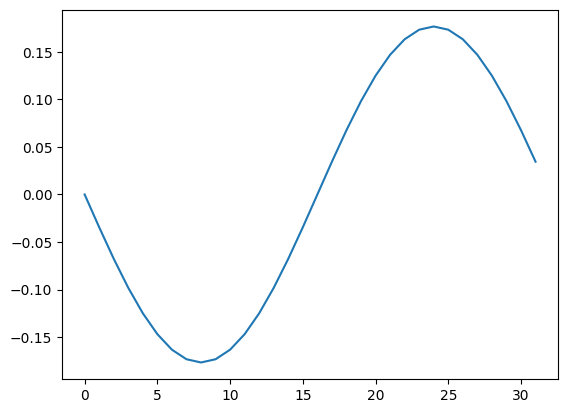

In [5]:
# Verify that the rows are the conjugate of the associated Fourier function
plt.plot(DFT[2**(N-1)+1,:].imag)

In [6]:
X = np.linspace(0,1,2**N,endpoint=False)
psi = np.exp(-((X - 0.5)**2) / (2 * 0.1**2))
#psi = np.ones(2**N)
psi = psi / np.linalg.norm(psi)  
T_final = 0.2
dt = 0.0002
Nt = int(T_final/dt)
interpolate= False

if interpolate:
    exp_kin = np.dot(DFT.T.conj(),np.diag(np.exp(-1j*np.diag(K_interp)*dt))).dot(DFT) 
    exp_pot = np.diag(np.exp(-1j*np.diag(P_interp)*dt/2))
else: 
    exp_kin = np.dot(DFT.T.conj(),np.diag(np.exp(-1j*np.diag(K)*dt))).dot(DFT) 
    exp_pot = np.diag(np.exp(-1j*np.diag(P)*dt/2))

In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.quantum_info import Statevector  
from walsh_trotterization import create_trotter_step_circuit
from circuit_constructor import create_pauli_rotation_circuit, create_fourier_basis_rotation_circuit
from walsh_pauli_decomposition import decompose_potential_term, decompose_laplacian_term
potential_decomp = decompose_potential_term(N, V0, interpolate=interpolate)
potential_circuit_half =  create_pauli_rotation_circuit(N, dt/2, potential_decomp)

kinetic_decomp = decompose_laplacian_term(N, interpolate=interpolate)
kinetic_circuit = create_fourier_basis_rotation_circuit(N, dt, kinetic_decomp)

simulator = AerSimulator(method='statevector')
state = Statevector(psi)
circuit = potential_circuit_half
trotter_step_circuit = create_trotter_step_circuit(N,dt,V0,interpolate=interpolate)
state_T = state.evolve(circuit)
state_K = state.evolve(kinetic_circuit)

[]
[3, 4]
[2, 4]
[1, 4]
[0, 4]
[2, 3]
[1, 3]
[0, 3]
[1, 2]
[0, 2]
[0, 1]
[]
[3, 4]
[2, 4]
[1, 4]
[0, 4]
[2, 3]
[1, 3]
[0, 3]
[1, 2]
[0, 2]
[0, 1]
[]
[3, 4]
[2, 4]
[1, 4]
[0, 4]
[2, 3]
[1, 3]
[0, 3]
[1, 2]
[0, 2]
[0, 1]


/var/folders/5r/lv4wdcg11yq4pn5l5lcnzwk40000gn/T/ipykernel_46378/1298866207.py:8: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  plt.plot(np.sum(HN[:,index]* coeff*2**(N/2) for index, coeff in indices.items()),'o')
/Users/fserret/.pyenv/versions/torch_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/fserret/.pyenv/versions/torch_env/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


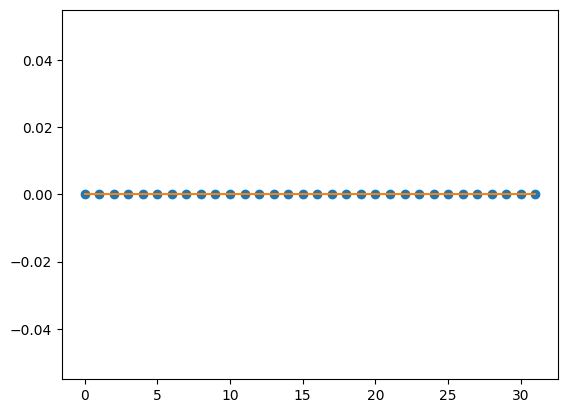

In [8]:
# Test that the potential is correctly represented by Walsh-Pauli in the qiskit msb basis
Hadamard = np.asarray([[1, 1],[1,-1]])/2**0.5
HN=1
for i in range (N):
    HN=np.kron(HN,Hadamard)
indices = {int(''.join(['0' if i == 'I' else '1' for i in string[::-1]]),base=2):coeff for string,coeff in potential_decomp.items()}
# MSB qiskit
plt.plot(np.sum(HN[:,index]* coeff*2**(N/2) for index, coeff in indices.items()),'o')
plt.plot(np.diag(P))

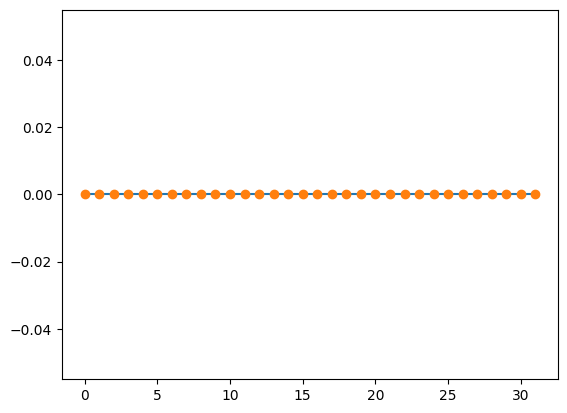

In [9]:
# Test that the angles for the rotation for the potential term are correct
plt.plot(np.angle((state_T.__array__())/state.__array__()*np.exp(-1j*np.angle((state_T.__array__())/state.__array__())[0])))
plt.plot(np.angle(np.diag(exp_pot)*np.exp(-1j*np.angle(np.diag(exp_pot))[0])),'o')

/var/folders/5r/lv4wdcg11yq4pn5l5lcnzwk40000gn/T/ipykernel_46378/4131763240.py:2: RuntimeWarning: divide by zero encountered in matmul
  plt.plot(np.angle(DFT@ exp_kin@psi/(DFT@psi)*np.exp(-1j*np.angle(DFT@ exp_kin@psi/(DFT@psi))[0])),'o')
/var/folders/5r/lv4wdcg11yq4pn5l5lcnzwk40000gn/T/ipykernel_46378/4131763240.py:2: RuntimeWarning: overflow encountered in matmul
  plt.plot(np.angle(DFT@ exp_kin@psi/(DFT@psi)*np.exp(-1j*np.angle(DFT@ exp_kin@psi/(DFT@psi))[0])),'o')
/var/folders/5r/lv4wdcg11yq4pn5l5lcnzwk40000gn/T/ipykernel_46378/4131763240.py:2: RuntimeWarning: invalid value encountered in matmul
  plt.plot(np.angle(DFT@ exp_kin@psi/(DFT@psi)*np.exp(-1j*np.angle(DFT@ exp_kin@psi/(DFT@psi))[0])),'o')
/var/folders/5r/lv4wdcg11yq4pn5l5lcnzwk40000gn/T/ipykernel_46378/4131763240.py:3: RuntimeWarning: divide by zero encountered in matmul
  plt.plot(np.angle(DFT@ state_K.__array__()/(DFT@state.__array__())*np.exp(-1j*np.angle(DFT@ state_K.__array__()/(DFT@state.__array__()))[0])))
/var/fo

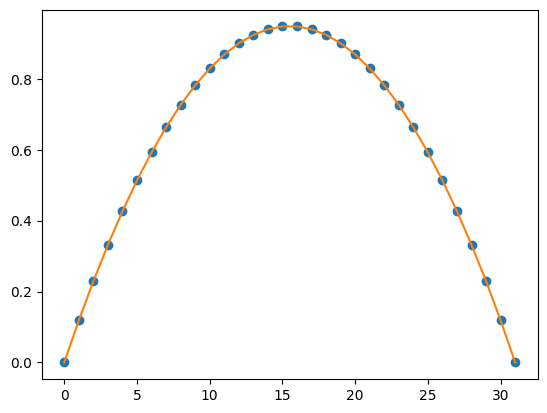

In [ ]:
# test that the angles in the QFT basis are correct
plt.plot(np.angle(DFT@ exp_kin@psi/(DFT@psi)*np.exp(-1j*np.angle(DFT@ exp_kin@psi/(DFT@psi))[0])),'o')
plt.plot(np.angle(DFT@ state_K.__array__()/(DFT@state.__array__())*np.exp(-1j*np.angle(DFT@ state_K.__array__()/(DFT@state.__array__()))[0])))


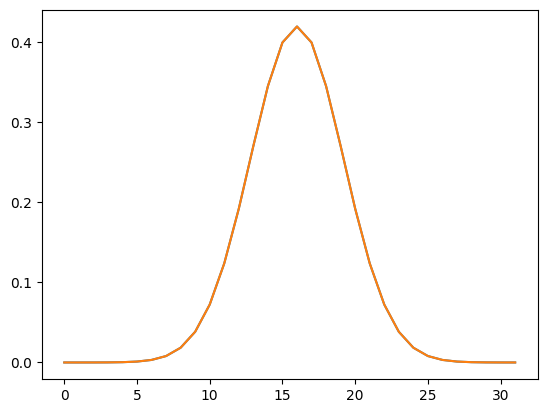

In [11]:
plt.plot(psi)
plt.plot(state.__array__())

In [ ]:
import copy
# Time evolve for Nt steps using numpy
res = copy.deepcopy(psi)
for i in range(Nt):
    res = exp_pot@exp_kin@exp_pot@res
    res = res / np.linalg.norm(res)

/var/folders/5r/lv4wdcg11yq4pn5l5lcnzwk40000gn/T/ipykernel_46378/2397563656.py:4: RuntimeWarning: divide by zero encountered in matmul
  res = exp_pot@exp_kin@exp_pot@res
/var/folders/5r/lv4wdcg11yq4pn5l5lcnzwk40000gn/T/ipykernel_46378/2397563656.py:4: RuntimeWarning: overflow encountered in matmul
  res = exp_pot@exp_kin@exp_pot@res
/var/folders/5r/lv4wdcg11yq4pn5l5lcnzwk40000gn/T/ipykernel_46378/2397563656.py:4: RuntimeWarning: invalid value encountered in matmul
  res = exp_pot@exp_kin@exp_pot@res


In [ ]:
import tqdm
# Time evolve for Nt steps using qiskit
state_end = state
for i in tqdm.tqdm(range(Nt)):
    state_end = state_end.evolve(trotter_step_circuit)

100%|██████████| 1000/1000 [00:00<00:00, 1058.21it/s]


Text(0.5, 0, 'x')

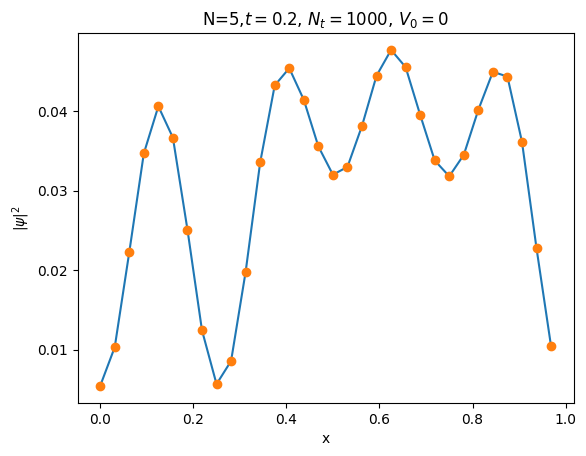

In [ ]:
# Evolution comparison between numpy and qiskit for |psi|^2

plt.plot(X,state_end.__array__()*state_end.__array__().conj())
plt.plot(X,res*res.conj(),'o')
plt.title(f'N={N},$t={dt*Nt}$, $N_t={Nt}$, $V_0={V0}$')
plt.ylabel(r"$|\psi|^2$")
plt.xlabel("x")

/Users/fserret/.pyenv/versions/torch_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/fserret/.pyenv/versions/torch_env/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


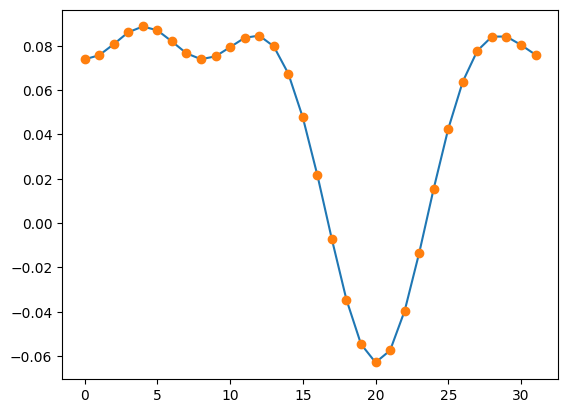

In [ ]:
# Evolution comparison between numpy and qiskit for psi with global phase set to 0
plt.plot(remove_global_phase(state_end.__array__())) 
plt.plot(remove_global_phase(res),'o')

In [31]:
# Comparison between Walsh truncation and interpolation

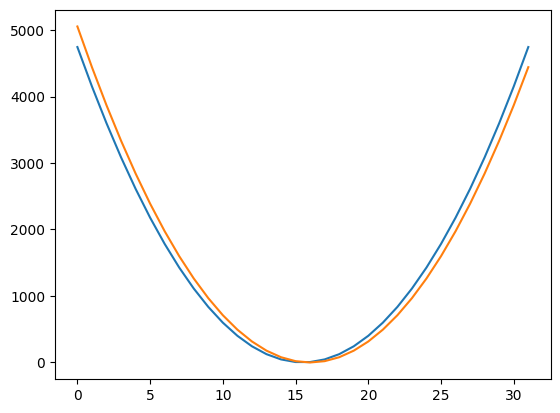

In [32]:
plt.plot(np.diag(K))
plt.plot(np.diag(K_interp))

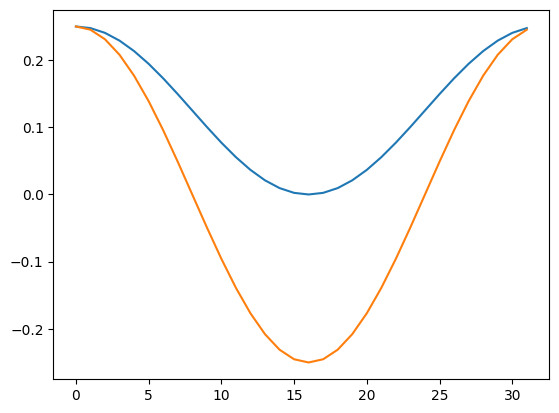

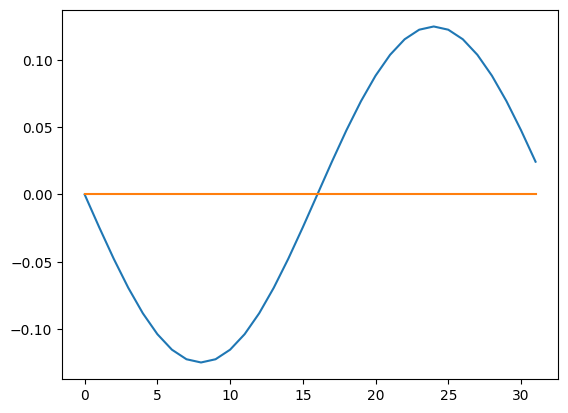

In [44]:
eigvals, eigvecs = np.linalg.eigh(P + K_x)
eigvals_interp, eigvecs_interp = np.linalg.eigh(P_interp + K_x_interp)
k=1
plt.plot(remove_global_phase(eigvecs[:,k]))
plt.plot(remove_global_phase(eigvecs_interp[:,k]))
plt.figure()
plt.plot(remove_global_phase(eigvecs[:,k].imag))
plt.plot(remove_global_phase(eigvecs_interp[:,k].imag))